# Сравнительный анализ сохранённых траекторий

Этот сценарий не запускает модель заново. Входные CSV должны быть получены
базовым экспериментом `01_dining_philosophers.jl`.

In [1]:
using DrWatson
@quickactivate "project"
ENV["GKSwstype"] = "100"
using CSV, DataFrames, Plots, Statistics
include(srcdir("dining_philosophers.jl"))
using .DiningPhilosophers

## Загрузка ранее полученных данных

In [2]:
const N = 5
const INPUT_DIR = datadir("01_dining_philosophers")
const OUTPUT_DIR = datadir("04_comparative_report")
const IMAGE_DIR = projectdir("..", "image")
classic_file = joinpath(INPUT_DIR, "classical_trajectory.csv")
arbiter_file = joinpath(INPUT_DIR, "arbiter_trajectory.csv")
for file in (classic_file, arbiter_file)
    isfile(file) || error("Сначала выполните базовый эксперимент: отсутствует $(basename(file))")
end
classical = CSV.read(classic_file, DataFrame)
arbiter = CSV.read(arbiter_file, DataFrame)
mkpath(OUTPUT_DIR)
mkpath(IMAGE_DIR)

"/workspace/labs/lab05/project/../image"

## Сопоставление позиций Eat

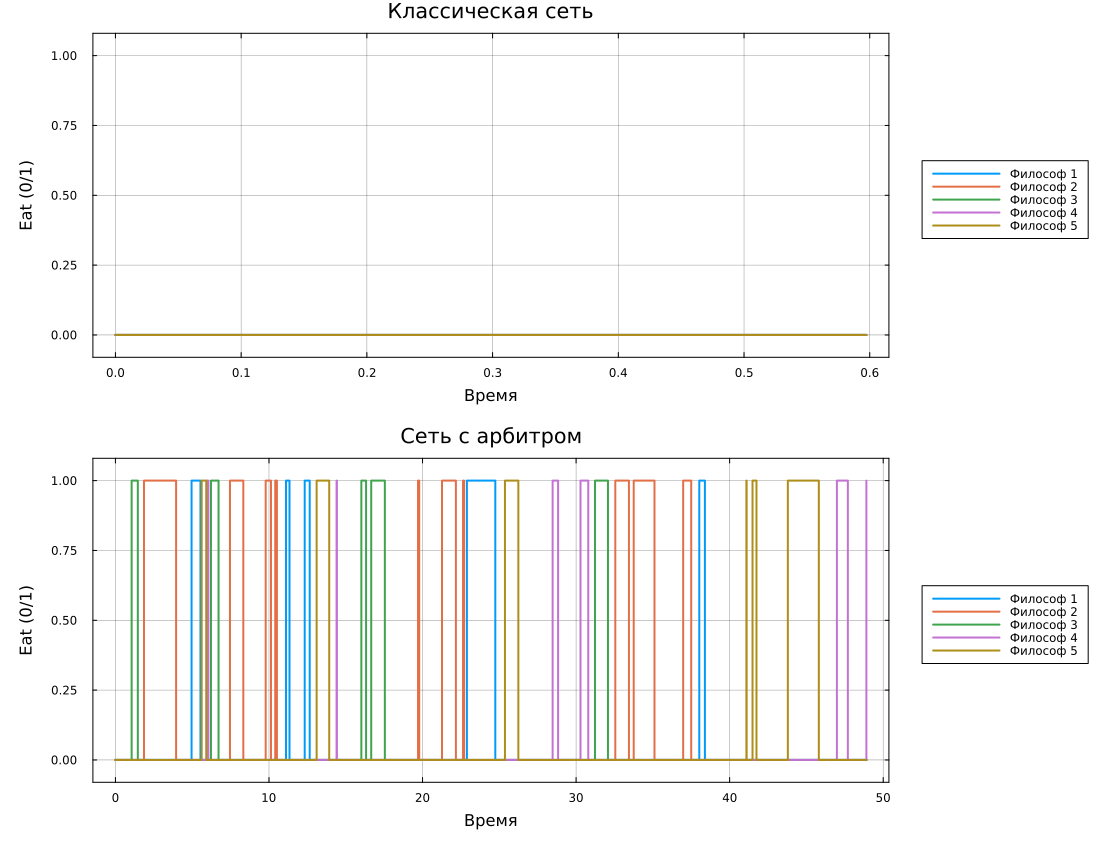

In [3]:
eat_columns = [Symbol("Eat_$i") for i in 1:N]
for trajectory in (classical, arbiter)
    all(name -> name in propertynames(trajectory), eat_columns) ||
        error("В CSV отсутствуют необходимые столбцы Eat")
    issorted(trajectory.time) || error("Временные отметки должны быть упорядочены")
end
default(fontfamily="DejaVu Sans", linewidth=2, framestyle=:box,
    gridalpha=0.22, left_margin=7Plots.mm, bottom_margin=5Plots.mm)
labels = permutedims(["Философ $i" for i in 1:N])
p1 = plot(classical.time, Matrix(classical[:, eat_columns]);
    label=labels, seriestype=:steppost, xlabel="Время", ylabel="Eat (0/1)",
    ylims=(-0.08, 1.08), title="Классическая сеть", legend=:outerright)
p2 = plot(arbiter.time, Matrix(arbiter[:, eat_columns]);
    label=labels, seriestype=:steppost, xlabel="Время", ylabel="Eat (0/1)",
    ylims=(-0.08, 1.08), title="Сеть с арбитром", legend=:outerright)
comparison = plot(p1, p2; layout=(2, 1), size=(1100, 850))
savefig(comparison, joinpath(IMAGE_DIR, "03-plot.png"))
display(comparison)

## Проверка последней маркировки

In [4]:
classic_net, _ = build_classical_network(N)
arbiter_net, _ = build_arbiter_network(N)
classic_last = Int[last(classical)[name] for name in classic_net.place_names]
arbiter_last = Int[last(arbiter)[name] for name in arbiter_net.place_names]
summary = DataFrame(variant=["Классическая", "С арбитром"],
    rows=[nrow(classical), nrow(arbiter)],
    last_event=[last(classical.time), last(arbiter.time)],
    deadlock=[detect_deadlock(classic_net, classic_last),
              detect_deadlock(arbiter_net, arbiter_last)],
    max_eating=[maximum(sum(Matrix(classical[:, eat_columns]); dims=2)),
                maximum(sum(Matrix(arbiter[:, eat_columns]); dims=2))])
CSV.write(joinpath(OUTPUT_DIR, "summary.csv"), summary)
show(summary; allrows=true, allcols=true)
println()

2×5 DataFrame
 Row │ variant       rows   last_event  deadlock  max_eating 
     │ String        Int64  Float64     Bool      Int64      
─────┼───────────────────────────────────────────────────────
   1 │ Классическая      6    0.597319      true           0
   2 │ С арбитром       99   48.9047       false           1


Нулевое значение Eat само по себе не доказывает deadlock. Проверка множества
разрешённых переходов отличает взаимную блокировку от временной паузы питания.